# Light GBM

In [5]:
# !pip uninstall -y lightgbm
# !git clone --recursive https://github.com/microsoft/LightGBM

In [6]:
# %%bash
# cd LightGBM/
# sh build-python.sh install --cuda

In [7]:
# %%bash
# cd LightGBM
# rm -r build
# mkdir build
# cd build
# cmake -DUSE_CUDA=1 -DOpenCL_LIBRARY=/usr/local/cuda-12.5/lib64/libOpenCL.so -DOpenCL_INCLUDE_DIR=/usr/local/cuda-12.5/include/ ..
# make -j$(nproc)

In [8]:
# %pip install lightgbm --config-settings=cmake.define.USE_CUDA=ON

In [9]:
# !rm -rf LightGBM/

In [10]:
%pip install \
  --no-binary lightgbm \
  --config-settings=cmake.define.USE_CUDA=ON \
  'lightgbm>=4.0.0'

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import json
import numpy as np
import pandas as pd
from sklearn import metrics
import cuml.metrics as cl_metrics
import matplotlib.pyplot as plt
from typing import Iterable

import cudf

warnings.filterwarnings('ignore')

DATA_PATH = './../data_numpy'
BEST_PARAMS_PATH = './../best_params/LGBM' 

In [3]:
Xtr = pd.read_csv(f'{DATA_PATH}/Xtr.csv')
Xval = pd.read_csv(f'{DATA_PATH}/Xval.csv')
Xte = pd.read_csv(f'{DATA_PATH}/Xte.csv')
ytr = pd.read_csv(f'{DATA_PATH}/ytr.csv')
yval = pd.read_csv(f'{DATA_PATH}/yval.csv')
yte = pd.read_csv(f'{DATA_PATH}/yte.csv')

Xtr_oversampled = pd.read_csv(f'{DATA_PATH}/Xtr_resampled.csv')
Xval_oversampled = pd.read_csv(f'{DATA_PATH}/Xval_resampled.csv')
Xte_oversampled = pd.read_csv(f'{DATA_PATH}/Xte_resampled.csv')
ytr_oversampled = pd.read_csv(f'{DATA_PATH}/ytr_resampled.csv')
yval_oversampled = pd.read_csv(f'{DATA_PATH}/yval_resampled.csv')
yte_oversampled = pd.read_csv(f'{DATA_PATH}/yte_resampled.csv')

# Load the datasets in the GPU
# Xtr = cudf.DataFrame(Xtr)
# Xval = cudf.DataFrame(Xtr)
# Xte = cudf.DataFrame(Xte)
# ytr = cudf.Series(ytr.values.flatten())
# yval = cudf.Series(yval.values.flatten())
# yte = cudf.Series(yte.values.flatten())

# Xtr_oversampled = cudf.DataFrame(Xtr_oversampled)
# Xval_oversampled = cudf.DataFrame(Xval_oversampled)
# Xte_oversampled = cudf.DataFrame(Xte_oversampled)
# ytr_oversampled = cudf.Series(ytr_oversampled.values.flatten())
# yval_oversampled = cudf.Series(yval_oversampled.values.flatten())
# yte_oversampled = cudf.Series(yte_oversampled.values.flatten())

## Cross validation

In [7]:
from functools import reduce
from operator import mul
import time
import lightgbm as lgb
from sklearn.model_selection import ParameterGrid


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        num_leaves: Iterable,
        max_depth: Iterable,
        learning_rate: Iterable,
        n_estimators: Iterable,
        min_child_samples: Iterable,
        subsample: Iterable,
        colsample_bytree: Iterable,
        random_state=1
):

    model_settings = {
        'objective': 'binary',
        'metric': 'roc_auc',
        'boosting_type': 'gbdt',
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'device': 'cuda',
    }

    # Cross validation parameters
    param_grid = {
        'num_leaves': num_leaves,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'min_child_samples': min_child_samples,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree
    }

    best_score = -1
    best_params = None

    fits = reduce(mul, [len(param) for param in param_grid.values()])

    categorical_cols = Xtr.select_dtypes(include=["object", "category"])
    categorical_idxs = [Xtr.columns.get_loc(col) for col in categorical_cols]
    # convert "object" to  "category"
    for col in categorical_cols:
        Xtr[col] = Xtr[col].astype('category')
        Xval[col] = Xval[col].astype('category')

    for i, curr_params in enumerate(ParameterGrid(param_grid)):
        timer = time.time()

        # train the model with different parameters
        # **params are the classifier parameters like the CUDA usage, **curr_params are the one
        # to cross validate
        model = lgb.LGBMClassifier(
            **model_settings, **curr_params, random_state=random_state)
        model.fit(Xtr, ytr, categorical_feature=categorical_idxs)

        # calculate the score
        y_pred = model.predict_proba(Xval)[:, 1]
        score = cl_metrics.roc_auc_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i+1}/{fits}] END score = {score:.6f} total time = {elapsed_time}")

        if score > best_score:
            best_score = score
            best_params = curr_params

    print(f"Best parameters: {best_params}")
    print(f"Best roc_auc score: {best_score}")

    return best_params, best_score

In [8]:
param_grid = {
    'num_leaves': [31, 50, 70, 90],
    'max_depth': [16],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [300],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(Xtr, ytr, Xval, yval, **param_grid)
    with open(f'{BEST_PARAMS_PATH}/best_params_gpu.json', 'w') as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f'{BEST_PARAMS_PATH}/best_params_gpu.json', 'r') as f:
        best_params = json.load(f)

print(f"Best params: {best_params}")
print(f"Best score: {best_score}")

Executing cross validation...
[fit 1/432] END score = 0.883968 total time = 11.2s
[fit 2/432] END score = 0.884039 total time = 11.0s
[fit 3/432] END score = 0.883435 total time = 11.1s
[fit 4/432] END score = 0.885086 total time = 16.5s
[fit 5/432] END score = 0.885265 total time = 16.9s
[fit 6/432] END score = 0.885347 total time = 16.8s
[fit 7/432] END score = 0.885219 total time = 21.8s
[fit 8/432] END score = 0.885209 total time = 21.2s
[fit 9/432] END score = 0.885504 total time = 20.1s
[fit 10/432] END score = 0.885807 total time = 24.7s
[fit 11/432] END score = 0.886443 total time = 25.7s
[fit 12/432] END score = 0.886830 total time = 25.0s
[fit 13/432] END score = 0.883672 total time = 11.3s
[fit 14/432] END score = 0.883789 total time = 10.4s
[fit 15/432] END score = 0.883993 total time = 11.0s
[fit 16/432] END score = 0.885240 total time = 16.1s
[fit 17/432] END score = 0.885449 total time = 16.1s
[fit 18/432] END score = 0.885352 total time = 15.2s
[fit 19/432] END score = 

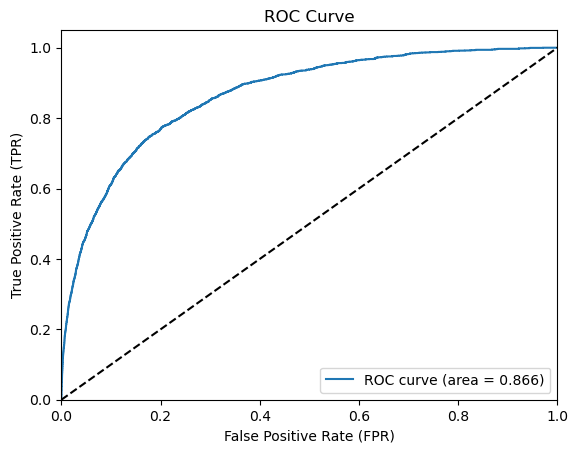

In [ ]:
model = lgb.LGBMClassifier(**best_params, random_state=1)
model.fit(Xtr, ytr)
y_pred = model.predict_proba(Xte)[:, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Oversampled dataset

In [9]:
choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(Xtr_oversampled, ytr_oversampled, Xval_oversampled, yval_oversampled, **param_grid)
    with open(f'{BEST_PARAMS_PATH}/../oversampling/LGBM/best_params_gpu.json', 'w') as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f'{BEST_PARAMS_PATH}/../oversampling/LGBM/best_params_gpu.json', 'r') as f:
        best_params = json.load(f)

print(f"Best params: {best_params}")
print(f"Best score: {best_score}")

Executing cross validation...
[fit 1/432] END score = 0.789793 total time = 15.2s
[fit 2/432] END score = 0.813269 total time = 12.9s
[fit 3/432] END score = 0.747847 total time = 13.4s
[fit 4/432] END score = 0.859551 total time = 18.3s
[fit 5/432] END score = 0.902338 total time = 17.0s
[fit 6/432] END score = 0.835074 total time = 17.7s
[fit 7/432] END score = 0.939584 total time = 23.3s
[fit 8/432] END score = 0.889007 total time = 22.7s
[fit 9/432] END score = 0.879613 total time = 23.4s
[fit 10/432] END score = 0.898846 total time = 28.6s
[fit 11/432] END score = 0.899670 total time = 30.9s
[fit 12/432] END score = 0.799489 total time = 31.4s
[fit 13/432] END score = 0.900387 total time = 13.7s
[fit 14/432] END score = 0.638943 total time = 12.8s
[fit 15/432] END score = 0.692204 total time = 13.0s
[fit 16/432] END score = 0.898298 total time = 18.4s
[fit 17/432] END score = 0.930074 total time = 18.3s
[fit 18/432] END score = 0.848542 total time = 16.7s
[fit 19/432] END score = 

[LightGBM] [Info] Number of positive: 6720, number of negative: 664733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2664
[LightGBM] [Info] Number of data points in the train set: 671453, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010008 -> initscore=-4.594297
[LightGBM] [Info] Start training from score -4.594297


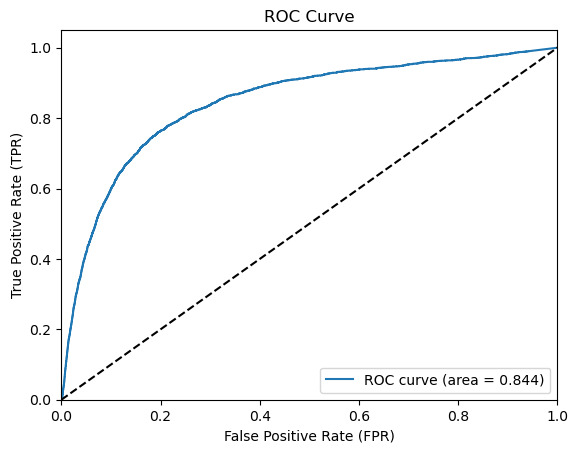

In [12]:
categorical_cols = Xtr.select_dtypes(include=["object", "category"])
categorical_idxs = [Xtr.columns.get_loc(col) for col in categorical_cols]
# convert "object" to  "category"
for col in categorical_cols:
    Xtr[col] = Xtr[col].astype('category')
    Xte[col] = Xte[col].astype('category')

model = lgb.LGBMClassifier(**best_params, random_state=1)
model.fit(Xtr, ytr, categorical_feature=categorical_idxs)
y_pred = model.predict_proba(Xte)[:, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()